# Deep Ensembles, Experiment 1: Toy regression (Figure 1)

**Reproduction of:** B. Lakshminarayanan, A. Pritzel, C. Blundell,
*Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles*,
NeurIPS 2017.

This notebook reproduces **Section 3.2 / Figure 1** of the paper: a 1-D toy
regression task that shows, panel by panel, *why* the method works.

The dataset is 20 points drawn as $y = x^3 + \varepsilon$ with
$\varepsilon \sim \mathcal{N}(0, 3^2)$. We compare four settings:

| Panel | Setting | What it shows |
|-------|---------|---------------|
| 1 | Empirical variance of 5 MSE networks | The common heuristic, *not* the paper's method |
| 2 | A single network trained with NLL | Effect of *learning* the variance |
| 3 | Single NLL network + adversarial training | Effect of adversarial smoothing |
| 4 | Ensemble of 5 NLL networks | Effect of *ensembling* |

The expected qualitative result (paper, Section 3.2): learning the variance
gives meaningful uncertainty, and the ensemble produces uncertainty that
**grows as we move away from the training data**.

## 1. Setup

We import the reproduction package (`src/`) and fix seeds.

In [1]:
import sys, os
# Make the src/ package importable when the notebook runs from notebooks/.
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
import matplotlib.pyplot as plt

from src import make_toy_dataset, toy_ground_truth, DeepEnsemble, MSEEnsemble
from src.adversarial import per_dimension_epsilon

# Reproducibility.
np.random.seed(0)
torch.manual_seed(0)

# Training hyper-parameters (paper Section 3.1 + Algorithm 1).
EPOCHS     = 400      # the toy set is tiny, so we use more epochs than UCI
BATCH_SIZE = 100      # full-batch here, since N = 20
LR         = 0.1      # Adam, fixed learning rate (paper Section 3.1)
M          = 5        # ensemble size (paper default)
HIDDEN     = (100,)   # 1 hidden layer, 100 units (architecture of [24])

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


## 2. The toy dataset

20 noisy training points. The plotting grid extends to $[-6, 6]$, wider than
the training range $[-4, 4]$, so we can see how each method behaves
**outside** the data, which is where uncertainty should grow.

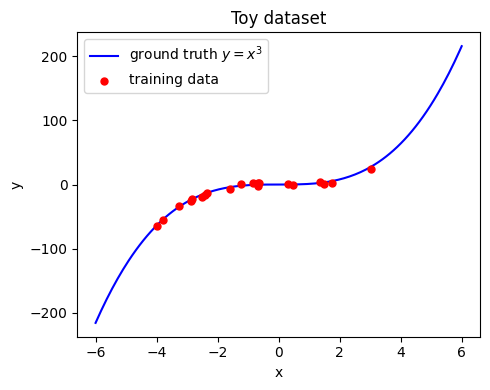

In [2]:
x_train, y_train = make_toy_dataset(n_points=20, noise_std=3.0,
                                    x_range=(-4.0, 4.0), seed=1)

# Grid for plotting the predictive distribution.
x_grid = np.linspace(-6.0, 6.0, 200).reshape(-1, 1).astype(np.float32)
y_true = toy_ground_truth(x_grid)

# Standardise inputs and targets (fit on the training data only).
x_mean, x_std = x_train.mean(), x_train.std()
y_mean, y_std = y_train.mean(), y_train.std()

def standardise_x(x): return (x - x_mean) / x_std
def standardise_y(y): return (y - y_mean) / y_std

xs_train = standardise_x(x_train)
ys_train = standardise_y(y_train)
xs_grid  = standardise_x(x_grid)

plt.figure(figsize=(5, 4))
plt.plot(x_grid, y_true, "b", label="ground truth $y=x^3$")
plt.scatter(x_train, y_train, c="r", s=25, zorder=3, label="training data")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Toy dataset")
plt.tight_layout(); plt.show()

## 3. A helper to draw one predictive panel

Each panel of Figure 1 shows: the ground-truth curve (blue), the training
points (red), the predicted mean and a $\pm 3\sigma$ band (grey). Predictions
are made in standardised space, so we convert mean and standard deviation back
to the original scale before plotting:

$$\mu_\text{orig} = \mu_\text{std}\, s_y + m_y, \qquad
  \sigma_\text{orig} = \sigma_\text{std}\, s_y .$$

In [3]:
def plot_panel(ax, mean_s, var_s, title):
    # Draw one Figure-1 panel from standardised mean / variance arrays.
    # Convert predictions back to the original target scale.
    mean = mean_s.ravel() * y_std + y_mean
    std  = np.sqrt(var_s.ravel()) * y_std

    ax.plot(x_grid.ravel(), y_true.ravel(), "b", lw=1.5, zorder=2)
    ax.scatter(x_train, y_train, c="r", s=18, zorder=3)
    ax.plot(x_grid.ravel(), mean, "k", lw=1.0, zorder=2)
    for k in (1, 2, 3):                       # nested +/- 1,2,3 sigma bands
        ax.fill_between(x_grid.ravel(), mean - k * std, mean + k * std,
                        color="gray", alpha=0.3, lw=0)
    ax.set_ylim(-250, 250)
    ax.set_xlim(-6, 6)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")

## 4. Panel 1: empirical variance of 5 MSE networks

The common heuristic: train 5 *plain* networks with MSE and use the empirical
variance of their predictions as uncertainty. The paper shows (and we should
see) that this uncertainty is **too small far from the data**, because the
networks agree even where they have no information.

In [4]:
mse_ens = MSEEnsemble(input_dim=1, hidden_dims=HIDDEN, M=M)
mse_ens.fit(xs_train, ys_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
            lr=LR, device=DEVICE)

mean1, var1 = mse_ens.predict(xs_grid, device=DEVICE)
print("panel 1 trained, empirical variance range:",
      float(var1.min()), float(var1.max()))

panel 1 trained, empirical variance range: 4.970851819052768e-07 0.04453513026237488


## 5. Panel 2: a single network trained with NLL

Now a single `GaussianMLP` that *outputs* a variance and is trained with the
Gaussian NLL (Equation 1). The variance is now **learned**, so the model can
express input-dependent (heteroscedastic) uncertainty.

We use `DeepEnsemble` with `M=1`, which is exactly one network.

In [5]:
single_nll = DeepEnsemble(input_dim=1, hidden_dims=HIDDEN, M=1,
                          adversarial=False)
single_nll.fit(xs_train, ys_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
               lr=LR, device=DEVICE)

mean2, var2 = single_nll.predict(xs_grid, device=DEVICE)
print("panel 2 trained, predicted variance range:",
      float(var2.min()), float(var2.max()))

panel 2 trained, predicted variance range: 0.0005893707275390625 0.115814208984375


## 6. Panel 3: single NLL network + adversarial training

Same single network, but now with adversarial training (FGSM, Section 2.3).
$\varepsilon$ is set to 1% of the input range, per dimension. Adversarial
training smooths the predictive distribution around each training point.

In [6]:
eps = per_dimension_epsilon(torch.tensor(xs_train), fraction=0.01)

single_nll_at = DeepEnsemble(input_dim=1, hidden_dims=HIDDEN, M=1,
                             adversarial=True, epsilon=eps)
single_nll_at.fit(xs_train, ys_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                  lr=LR, device=DEVICE)

mean3, var3 = single_nll_at.predict(xs_grid, device=DEVICE)
print("panel 3 trained, epsilon (standardised):", float(eps))

panel 3 trained, epsilon (standardised): 0.03627242520451546


## 7. Panel 4: ensemble of 5 NLL networks

Finally, the full method: an ensemble of `M = 5` `GaussianMLP`s. The combined
predictive variance (Section 2.4 mixture formula) should now **grow clearly as
we move away from the training data**, which is the key qualitative result.

In [7]:
ensemble = DeepEnsemble(input_dim=1, hidden_dims=HIDDEN, M=M,
                        adversarial=False)
ensemble.fit(xs_train, ys_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
             lr=LR, device=DEVICE)

mean4, var4 = ensemble.predict(xs_grid, device=DEVICE)
print("panel 4 trained, ensemble variance range:",
      float(var4.min()), float(var4.max()))

panel 4 trained, ensemble variance range: 2.914247751235962 36.691383361816406


## 8. Reproducing Figure 1

The four panels side by side, as in the paper. The figure is also saved to
`results/figure1_toy_regression.png` for the report.

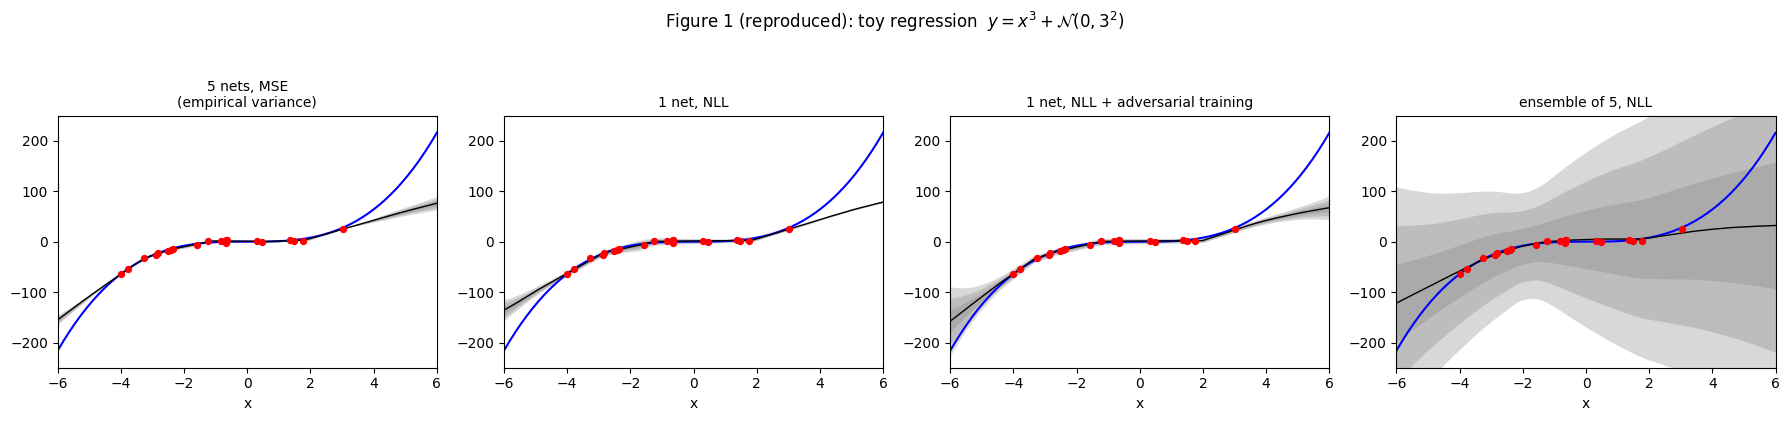

saved -> results/figure1_toy_regression.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

plot_panel(axes[0], mean1, var1, "5 nets, MSE\n(empirical variance)")
plot_panel(axes[1], mean2, var2, "1 net, NLL")
plot_panel(axes[2], mean3, var3, "1 net, NLL + adversarial training")
plot_panel(axes[3], mean4, var4, "ensemble of 5, NLL")

fig.suptitle("Figure 1 (reproduced): toy regression  $y = x^3 + \\mathcal{N}(0,3^2)$",
             y=1.04, fontsize=12)
fig.tight_layout()

os.makedirs("../results", exist_ok=True)
fig.savefig("../results/figure1_toy_regression.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("saved -> results/figure1_toy_regression.png")

## 9. Observations

Comparing the four panels against the paper's Figure 1:

* **Panel 1 (MSE empirical variance).** The grey band is narrow and stays
  narrow even far from the data. Plain networks trained with MSE tend to agree
  outside the training range, so their empirical variance *underestimates*
  uncertainty. This is the failure mode the paper points out.

* **Panel 2 (single NLL network).** Learning the variance gives a more honest
  uncertainty near the data, but a *single* network can still be overconfident
  far from it.

* **Panel 3 (+ adversarial training).** Adversarial training smooths the
  predictive distribution. The effect on this 1-D toy task is small, which is
  consistent with the paper's remark that adversarial training "helps on some
  datasets for some metrics and is not strictly necessary in all cases."

* **Panel 4 (ensemble of 5).** The predictive band widens markedly as we move
  away from the 20 training points. This is the main qualitative result:
  **ensembling captures model uncertainty**, since the disagreement between
  equally plausible networks grows where there is no data.

These match the paper's two conclusions for the toy task: (i) learning the
variance with a proper scoring rule improves uncertainty, and (ii) ensembling
improves it further, *especially* away from the training data.